### Celda 1 — Importar librerías
Carga de librerías para análisis de datos, visualización y modelado. 📦

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.0
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.4


# 📌 Fase 2 - Conexión a PostgreSQL
Conexión al motor de base de datos y preparación del entorno para análisis.

### Celda 2 — Cargar datos
Extracción de datos desde PostgreSQL mediante consulta SQL. 🗄️

In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

QUERY = """
SELECT
    s.nombre        AS superheroe,
    s.editorial,
    p.inteligencia,
    p.fuerza,
    p.velocidad,
    p.durabilidad,
    p.poder,
    p.combate,
    p.fecha_extraccion
FROM powerstats p
JOIN superheroes s ON p.superhero_id = s.id
ORDER BY p.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print("\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 3,535
   Columnas : 9

📋 Primeras filas:


,superheroe,editorial,inteligencia,fuerza,velocidad,durabilidad,poder,combate,fecha_extraccion
0,Iron Man,None,64,80,48,56,60,69,2026-03-27 20:26:54.563881
1,Captain Hindsight,None,66,83,90,68,74,60,2026-03-27 20:36:54.563881
2,Captain Midnight,None,59,72,71,100,75,63,2026-03-27 20:46:54.563881
3,Iron Man,None,63,79,60,63,63,53,2026-03-27 20:56:54.563881
4,Captain Hindsight,None,57,100,95,69,86,65,2026-03-27 21:06:54.563881


### Celda 2.5 — Limpieza e imputación de valores nulos
Realiza una limpieza básica de los datos imputando valores faltantes en las métricas numéricas.🧹

In [3]:
# ── CELDA 2.5: Limpieza de valores nulos (sobrescribe df) ───────

print("🧹 Limpieza de valores nulos en métricas numéricas")

metricas = [
    "inteligencia",
    "fuerza",
    "velocidad",
    "durabilidad",
    "poder",
    "combate"
]

# Asegurar que trabajamos sobre una copia
df = df.copy()

# 1️⃣ Imputación por superhéroe (media por grupo)
for col in metricas:
    df[col] = (
        df.groupby("superheroe")[col]
          .transform(lambda x: x.fillna(x.mean()))
    )

# 2️⃣ Imputación global (por si queda algún NaN)
df[metricas] = df[metricas].fillna(df[metricas].mean())

print("✅ Limpieza completada")
print("\n📊 Valores nulos restantes:")
print(df.isnull().sum())


🧹 Limpieza de valores nulos en métricas numéricas
✅ Limpieza completada

📊 Valores nulos restantes:
superheroe             0
editorial           3535
inteligencia           0
fuerza                 0
velocidad              0
durabilidad            0
poder                  0
combate                0
fecha_extraccion       0
dtype: int64


## Celda 3 — Inspección inicial del DataFrame
Verifica tipos de datos, valores nulos y forma general del dataset.🔍

In [4]:
# ── CELDA 3: Inspección inicial del DataFrame ─────────────────

print("=" * 55)
print("  INFORMACIÓN GENERAL DEL DATASET - SUPERHÉROES")
print("=" * 55)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🦸‍♂️ Superhéroes en el dataset:")
print(df['superheroe'].value_counts())

print("\n📚 Distribución por editorial:")
print(df['editorial'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET - SUPERHÉROES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3535 entries, 0 to 3534
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   superheroe        3535 non-null   object        
 1   editorial         0 non-null      object        
 2   inteligencia      3535 non-null   int64         
 3   fuerza            3535 non-null   int64         
 4   velocidad         3535 non-null   int64         
 5   durabilidad       3535 non-null   int64         
 6   poder             3535 non-null   int64         
 7   combate           3535 non-null   int64         
 8   fecha_extraccion  3535 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 248.7+ KB
None

📊 Valores nulos por columna:
superheroe             0
editorial           3535
inteligencia           0
fuerza                 0
velocidad              0
durabilidad          

# 📌 Fase 3 - Análisis Exploratorio de Datos (EDA)
Exploración de patrones, distribuciones y relaciones entre variables.

### Celda 4 — Estadísticas descriptivas[texto del enlace](https://)
Resumen numérico de variables clave del dataset. 📊

In [5]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = [
    'inteligencia',
    'fuerza',
    'velocidad',
    'durabilidad',
    'combate',
    'poder'
]

# ── ESTADÍSTICAS CON FILAS RESALTADAS ───────────────────────

desc = df[vars_num].describe().round(2)

def resaltar_filas(row):
    # Definimos los colores (puedes cambiarlos a tu gusto)
    color_promedio = 'background-color: #D6EAF8' # Azul claro
    color_mediana = 'background-color: #D5F5E3'  # Verde claro

    if row.name == 'mean':
        return [color_promedio] * len(row)
    if row.name == '50%':
        return [color_mediana] * len(row)
    return [''] * len(row)

# Aplicamos el estilo
styled_table = desc.style.apply(resaltar_filas, axis=1) \
    .format("{:.2f}") \
    .set_caption("📊 ESTADÍSTICAS DESCRIPTIVAS — POWERSTATS")

# Mostrar
styled_table

,inteligencia,fuerza,velocidad,durabilidad,combate,poder
count,3535.00,3535.00,3535.00,3535.00,3535.00,3535.00
mean,68.43,76.53,70.53,77.39,75.45,72.86
std,15.71,14.03,15.67,12.22,11.74,7.67
min,40.00,41.00,41.00,46.00,50.00,49.00
25%,55.00,67.00,57.00,68.50,67.00,67.00
50%,67.00,79.00,74.00,78.00,76.00,73.00
75%,81.00,87.00,84.00,87.00,85.00,78.00
max,100.00,100.00,100.00,100.00,100.00,100.00


### Celda 5 — Distribución de variables numéricas
Histogramas para detectar asimetría, outliers y rangos. 📈

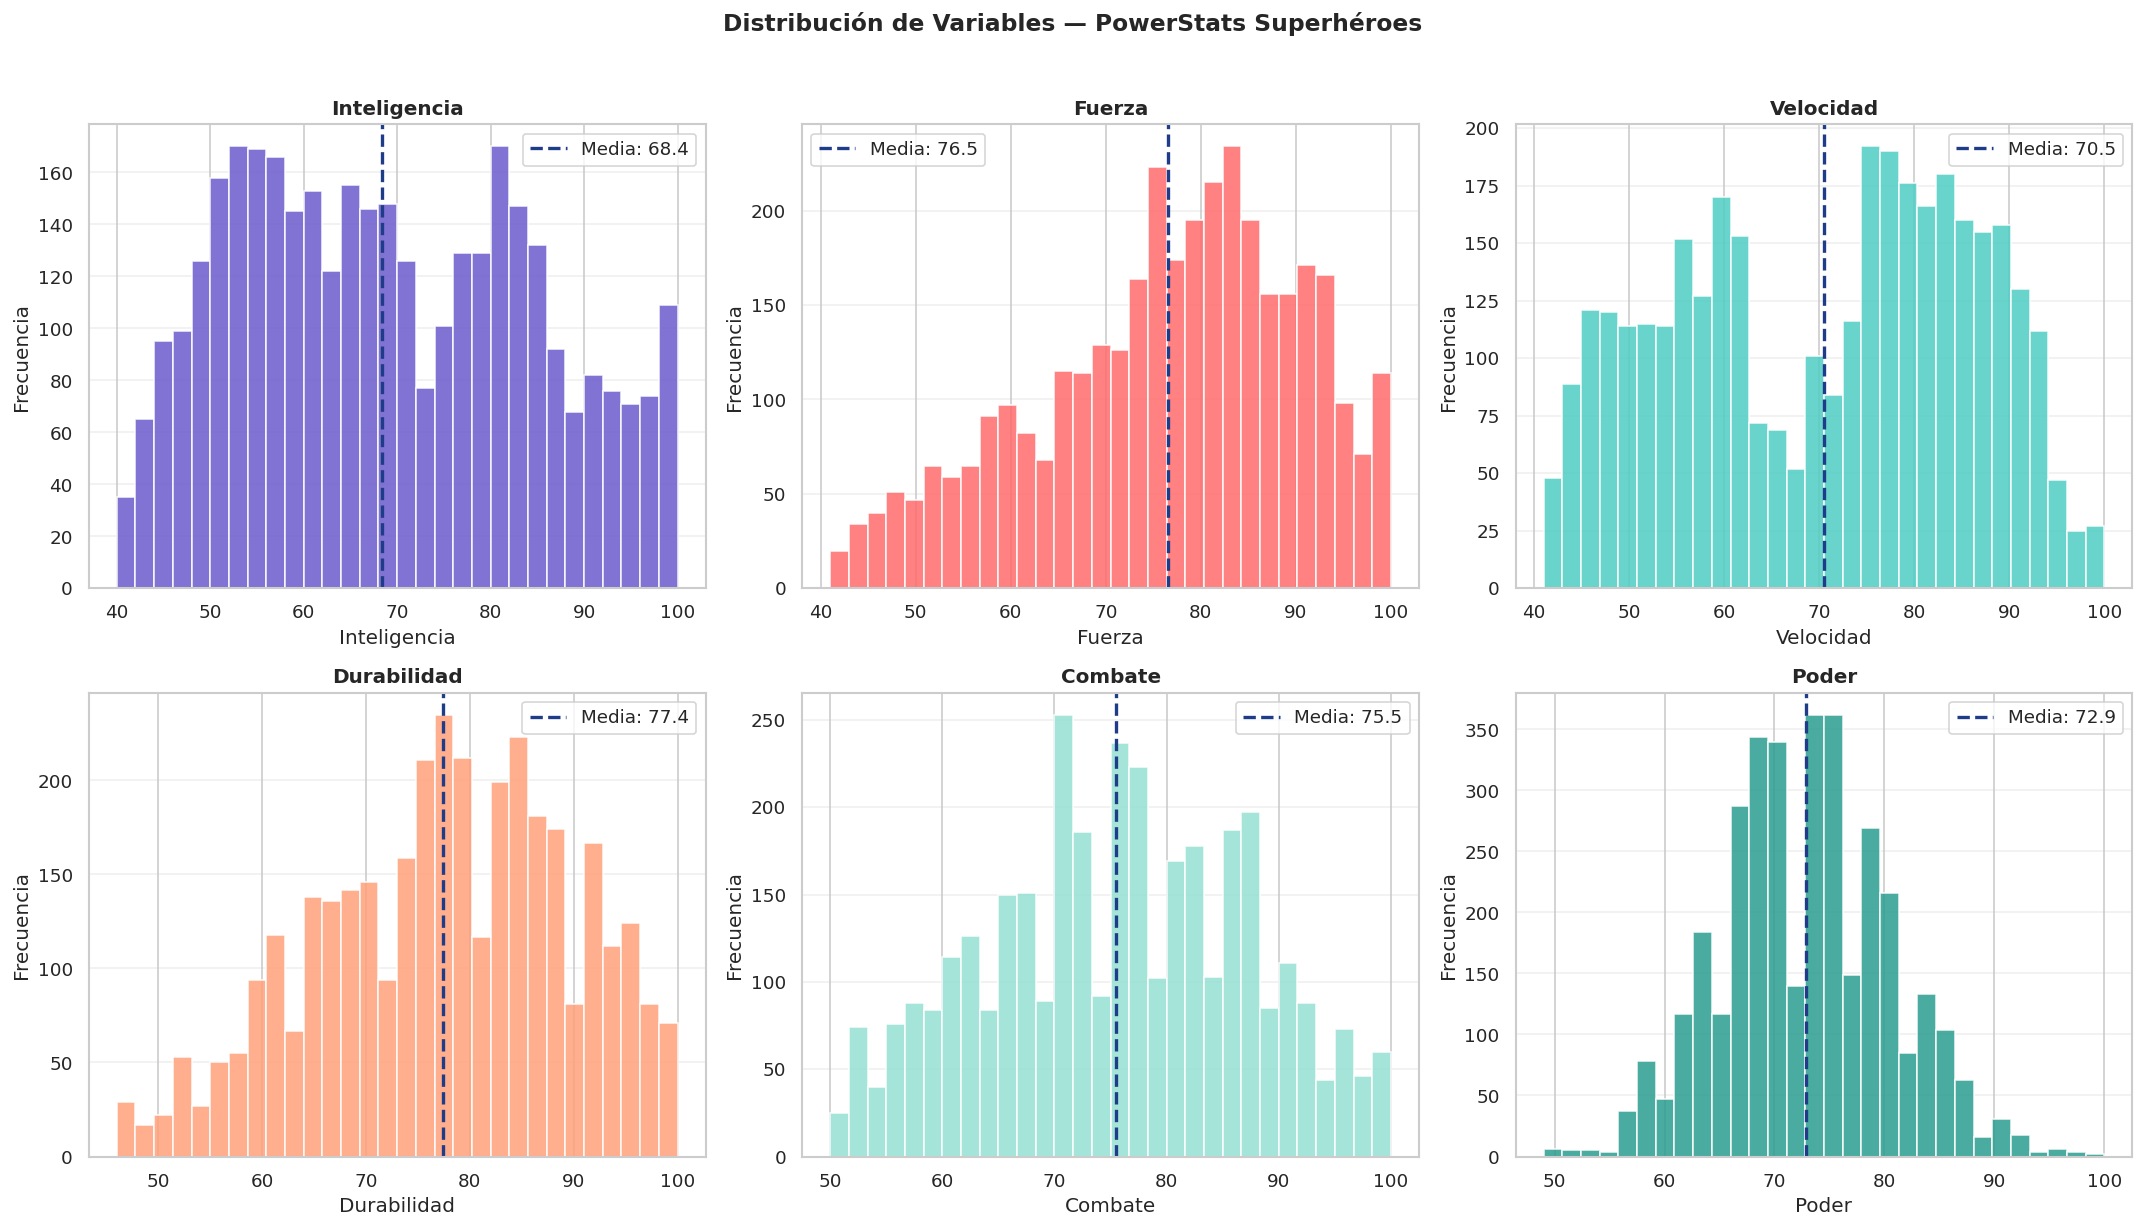

In [6]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Distribución de Variables — PowerStats Superhéroes',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

datos = {
    'inteligencia': ('Inteligencia', '#6a5acd'),
    'fuerza':       ('Fuerza', '#ff6b6b'),
    'velocidad':    ('Velocidad', '#4ecdc4'),
    'durabilidad':  ('Durabilidad', '#ffa07a'),
    'combate':      ('Combate', '#95e1d3'),
    'poder':        ('Poder', '#2a9d8f'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(
        media,
        color='#1f3c88',
        linestyle='--',
        linewidth=2,
        label=f'Media: {media:.1f}'
    )
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_distribuciones_powerstats.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 6 — Boxplots por superhéroe (Top 10 por poder)
Visualiza la distribución de las métricas de **fuerza** y **poder** para los 10 superhéroes con mayor poder promedio.  

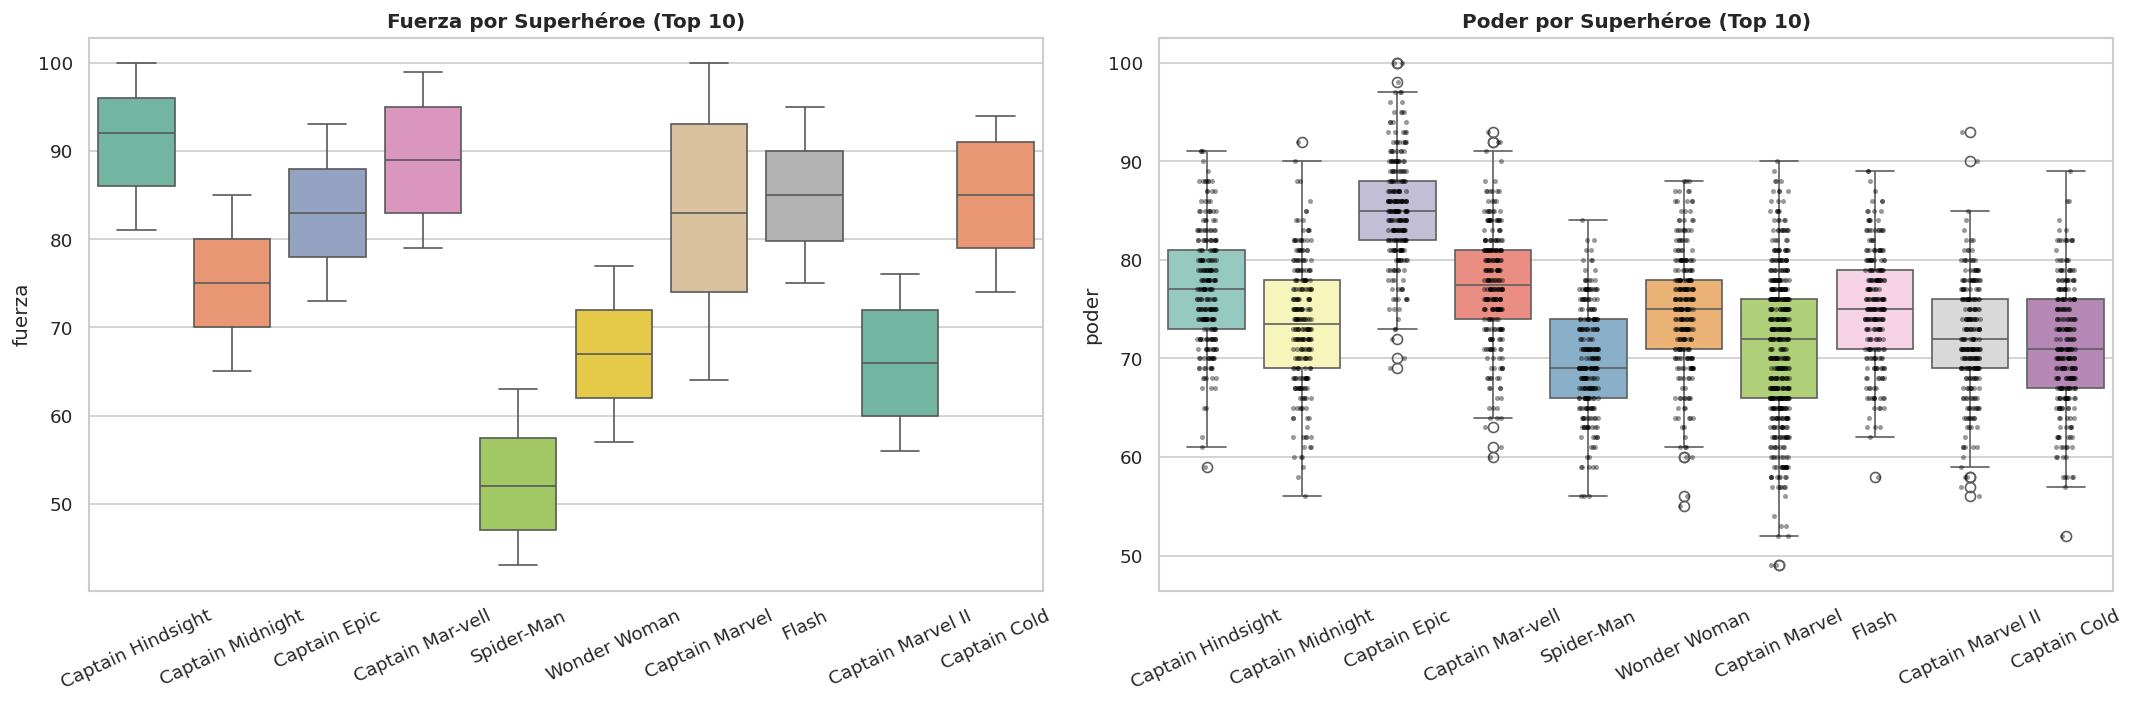

In [7]:
# ── CELDA 6: Boxplots por Superhéroe (Top 10 por Poder) ──────

# Seleccionar top 10 superhéroes por poder promedio
top_heroes = (
    df.groupby('superheroe')['poder']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = df[df['superheroe'].isin(top_heroes)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Fuerza por superhéroe ─────────────────────────────
sns.boxplot(
    data=df_top,
    x='superheroe',
    y='fuerza',
    hue='superheroe',
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Fuerza por Superhéroe (Top 10)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

# ── Poder por superhéroe (boxplot + puntos) ───────────
sns.boxplot(
    data=df_top,
    x='superheroe',
    y='poder',
    hue='superheroe',          # 🔑 CLAVE
    palette='Set3',
    legend=False,
    ax=axes[1]
)

sns.stripplot(
    data=df_top,
    x='superheroe',
    y='poder',
    color='black',
    size=3,
    alpha=0.4,
    jitter=True,
    ax=axes[1]
)

axes[1].set_title('Poder por Superhéroe (Top 10)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_boxplots_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 7 — Matriz de correlación
Identificación de relaciones entre variables numéricas. 🔗

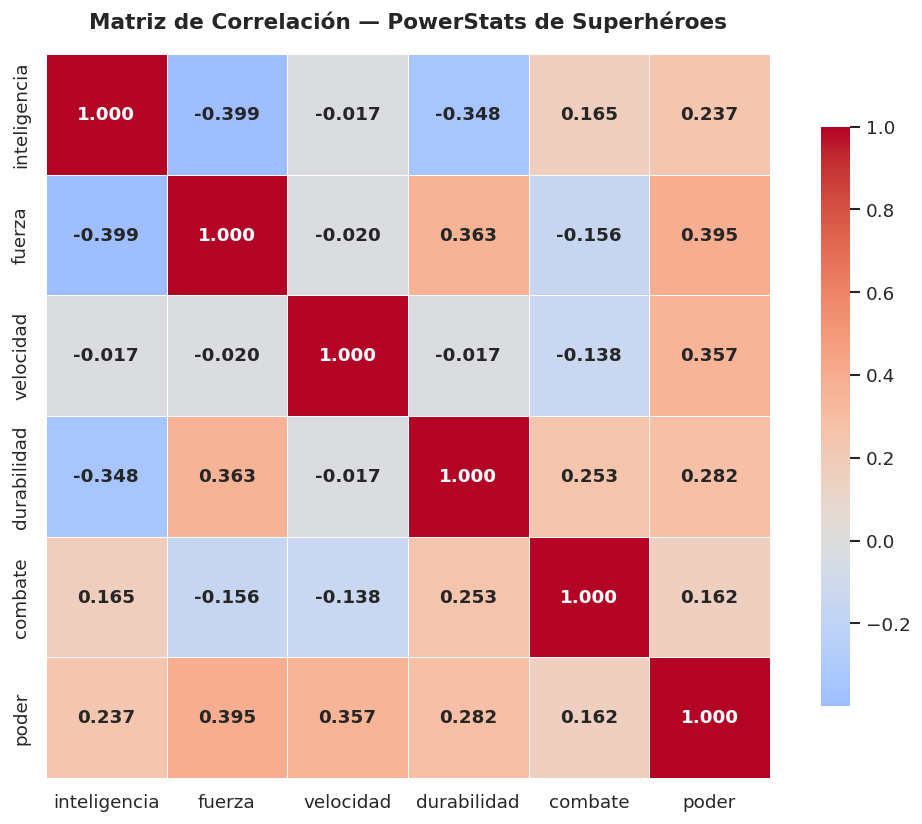


📊 Correlación con PODER (ordenada):
fuerza          0.3947
velocidad       0.3571
durabilidad     0.2822
inteligencia    0.2372
combate         0.1623
Name: poder, dtype: float64


In [8]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

corr = df[vars_num].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title(
    'Matriz de Correlación — PowerStats de Superhéroes',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_correlacion_powerstats.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("\n📊 Correlación con PODER (ordenada):")
print(
    corr['poder']
    .drop('poder')
    .sort_values(ascending=False)
    .round(4)
)

## Celda 8 — Scatter plots bivariados
Visualiza la relación lineal entre las features y la variable objetivo (poder). 🎯


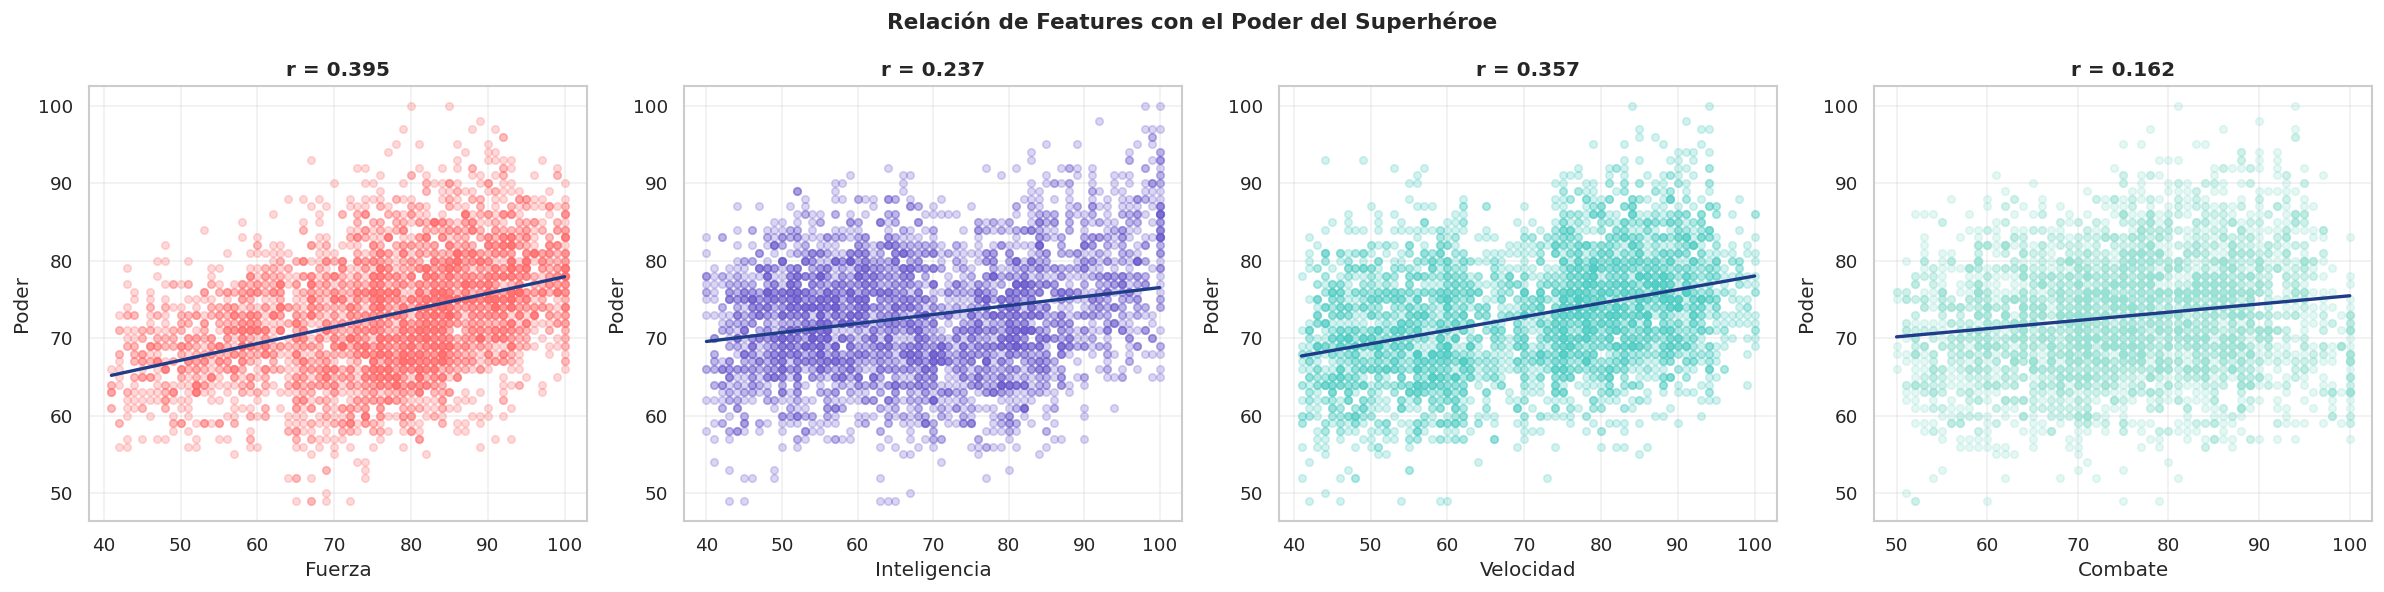

In [9]:
# ── CELDA 8: Scatter plots features vs poder (ROBUSTA) ───────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Relación de Features con el Poder del Superhéroe',
    fontsize=13,
    fontweight='bold'
)

pares = [
    ('fuerza',       'Fuerza',       '#ff6b6b'),
    ('inteligencia', 'Inteligencia', '#6a5acd'),
    ('velocidad',    'Velocidad',    '#4ecdc4'),
    ('combate',      'Combate',      '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    # Seleccionar solo datos válidos
    df_clean = df[[feature, 'poder']].copy()

    # Convertir a numérico y limpiar
    df_clean[feature] = pd.to_numeric(df_clean[feature], errors='coerce')
    df_clean['poder'] = pd.to_numeric(df_clean['poder'], errors='coerce')
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

    # Scatter
    ax.scatter(
        df_clean[feature],
        df_clean['poder'],
        alpha=0.25,
        s=20,
        color=color
    )

    # Solo ajustar línea si hay suficientes datos
    if len(df_clean) > 2 and df_clean[feature].nunique() > 1:
        z = np.polyfit(df_clean[feature], df_clean['poder'], 1)
        p = np.poly1d(z)
        xp = np.linspace(
            df_clean[feature].min(),
            df_clean[feature].max(),
            200
        )
        ax.plot(xp, p(xp), color='#1f3c88', linewidth=2)

        r = df_clean[[feature, 'poder']].corr().iloc[0, 1]
        ax.set_title(f'r = {r:.3f}', fontweight='bold')
    else:
        ax.set_title('Datos insuficientes', fontweight='bold')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Poder')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_scatter_powerstats.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# 📌 Fase 4 - Regresión Lineal Simple
Modelo para analizar relación entre fuerza y poder.

## Celda 9 — Preparar datos y dividir train/test
División del dataset en entrenamiento y prueba. ⚙️

In [10]:
# ── CELDA 9: Preparar datos y Split Train / Test (LIMPIO) ────

# Seleccionar solo filas válidas para regresión
df_modelo = df[['fuerza', 'poder']].dropna()

# Variables
X_simple = df_modelo[['fuerza']].values
y = df_modelo['poder'].values

# División 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Dataset limpio para regresión")
print(f"Filas totales usadas : {len(df_modelo):,}")
print(f"Train: {len(X_train):,} muestras ({len(X_train)/len(y)*100:.0f}%)")
print(f"Test : {len(X_test):,} muestras  ({len(X_test)/len(y)*100:.0f}%)")

✅ Dataset limpio para regresión
Filas totales usadas : 3,535
Train: 2,828 muestras (80%)
Test : 707 muestras  (20%)


### Celda 10 — Entrenar el modelo (scikit-learn)
Ajuste del modelo de regresión lineal simple. 🧠


In [11]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

# Predicciones
y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(
    f"\nEcuación : poder = {modelo_simple.intercept_:.3f}"
    f" + {modelo_simple.coef_[0]:.3f} × fuerza"
)

Intercepto  β₀ : 56.3459
Coeficiente β₁ : 0.2152

Ecuación : poder = 56.346 + 0.215 × fuerza


### Celda 11 — Visualizar la recta de regresión
Representación gráfica de la recta de regresión. 📉

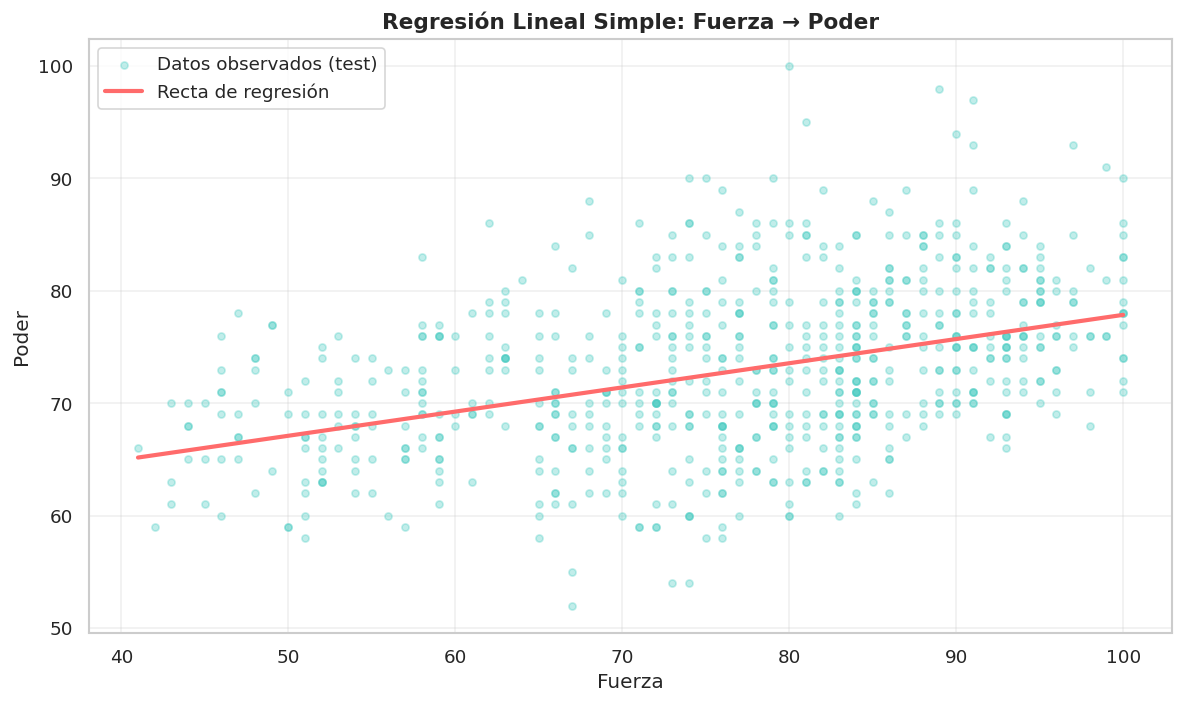

In [12]:
# ── CELDA 11: Recta de regresión ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter de datos reales (test)
ax.scatter(
    X_test,
    y_test,
    alpha=0.35,
    s=18,
    color='#4ecdc4',
    label='Datos observados (test)'
)

# Recta de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(
    x_line,
    modelo_simple.predict(x_line),
    color='#ff6b6b',
    linewidth=2.5,
    label='Recta de regresión'
)

ax.set_xlabel('Fuerza', fontsize=12)
ax.set_ylabel('Poder', fontsize=12)
ax.set_title(
    'Regresión Lineal Simple: Fuerza → Poder',
    fontsize=13,
    fontweight='bold'
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/regresion_simple_fuerza_poder.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 12 — Métricas de evaluación
Medición del rendimiento del modelo con métricas. 📏

In [13]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 50)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (SUPERHÉROES)")
print("=" * 50)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f}")
print(f"  MAE  (error absoluto med)   : {mae:.4f}")
print("=" * 50)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (SUPERHÉROES)
  R²   (coef. determinación)  : 0.1669  (16.69%)
  MSE  (error cuadrático med) : 46.1980
  RMSE (raíz del MSE)         : 6.7969
  MAE  (error absoluto med)   : 5.3912


### Celda 13 — Resumen OLS con statsmodels
Análisis estadístico detallado del modelo. 📚

In [14]:
# ── CELDA 13: OLS statsmodels — resumen completo (CORREGIDA) ──

# Usar el mismo DataFrame limpio que en la regresión
df_ols = df_modelo.copy()

# Variable explicativa con constante
X_ols = sm.add_constant(df_ols['fuerza'])

# Variable objetivo
y_ols = df_ols['poder']

# Ajuste del modelo OLS
modelo_ols_simple = sm.OLS(y_ols, X_ols).fit()

# Mostrar resumen
print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  poder   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     651.9
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          4.19e-132
Time:                        16:18:04   Log-Likelihood:                -11920.
No. Observations:                3535   AIC:                         2.384e+04
Df Residuals:                    3533   BIC:                         2.386e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.3391      0.658     85.664      0.0

### Celda 14 — Normalidad de residuos: Histograma + Q-Q Plot + Test Shapiro-Wilk
Validación del supuesto de normalidad en errores. 🔬

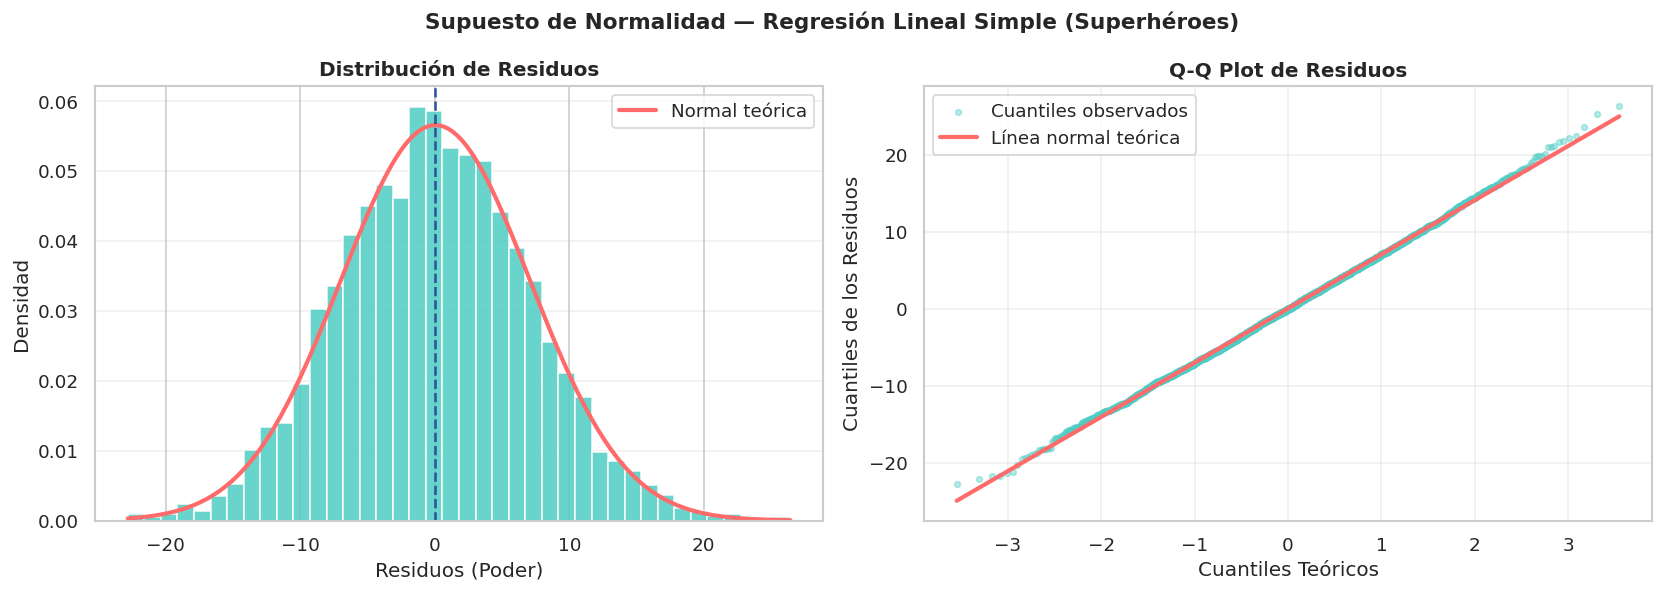


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9994
   p-value       : 0.379542
   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)


In [15]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────

# Predicciones sobre el dataset limpio
y_pred_all = modelo_simple.predict(df_modelo[['fuerza']].values)

# Residuos
residuos = df_modelo['poder'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Supuesto de Normalidad — Regresión Lineal Simple (Superhéroes)',
    fontsize=13,
    fontweight='bold'
)

# -------------------------------------------------
# Histograma con curva normal
# -------------------------------------------------
axes[0].hist(
    residuos,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (Poder)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# -------------------------------------------------
# Q-Q Plot
# -------------------------------------------------
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(
    osm,
    osr,
    alpha=0.4,
    s=12,
    color='#4ecdc4',
    label='Cuantiles observados'
)
axes[1].plot(
    osm,
    slope * np.array(osm) + intercept,
    color='#ff6b6b',
    linewidth=2.5,
    label='Línea normal teórica'
)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/normalidad_simple_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# -------------------------------------------------
# Test Shapiro-Wilk (máx 5000 observaciones)
# -------------------------------------------------
rng = np.random.default_rng(42)
muestra_sw = (
    residuos if len(residuos) <= 5000
    else rng.choice(residuos, 5000, replace=False)
)

stat_sw, p_sw = stats.shapiro(muestra_sw)

print("\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con muestras grandes, el test es muy sensible; revisar Q-Q plot")

### Celda 15 — Homocedasticidad: Residuos vs Valores Ajustados + Test Breusch-Pagan
Evaluación de la varianza constante en los residuos. ⚖️

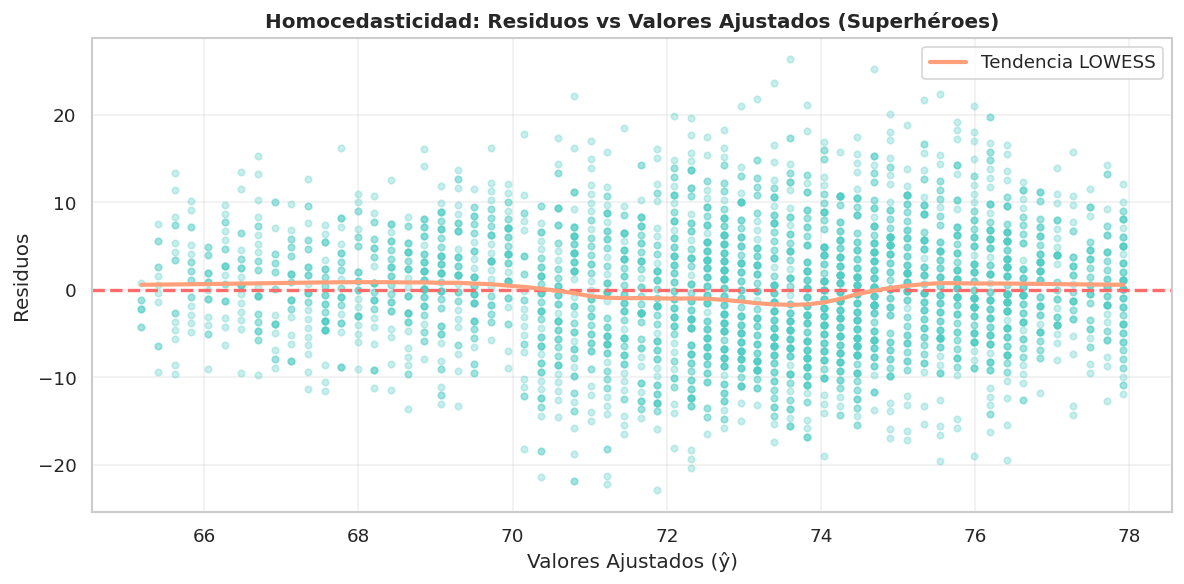


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 7.5217
   p-value        : 0.006096
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)


In [16]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

# Residuos y valores ajustados del modelo OLS
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(
    ajustados_ols,
    residuos_ols,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea de tendencia LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(
    lowess[:, 0],
    lowess[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='Tendencia LOWESS'
)

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title(
    'Homocedasticidad: Residuos vs Valores Ajustados (Superhéroes)',
    fontsize=12,
    fontweight='bold'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../data/graficas/homoc_simple_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# -------------------------------------------------
# Test de Breusch-Pagan
# -------------------------------------------------
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print("\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

# 📌 Fase 5 - Regresión Lineal Múltiple

### Celda 16 — Preparar datos y entrenamiento múltiple
Construcción del modelo con varias variables. 🧠

In [17]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──

FEATURES = ['fuerza', 'inteligencia', 'combate']

# Dataset limpio SOLO para el modelo múltiple
df_modelo_multi = df[FEATURES + ['poder']].dropna()

X_multi = df_modelo_multi[FEATURES].values
y = df_modelo_multi['poder'].values

# Split 80/20
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y,
    test_size=0.20,
    random_state=42
)

# Entrenamiento
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# Predicciones
y_pred_multi = modelo_multi.predict(X_test_m)

print("✅ Modelo múltiple entrenado correctamente\n")
print(f"Intercepto  β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>12} : {coef:.4f}")

print(
    "\nEcuación del modelo:\n"
    f"poder = {modelo_multi.intercept_:.3f} "
    f"+ {modelo_multi.coef_[0]:.3f}·fuerza "
    f"+ {modelo_multi.coef_[1]:.3f}·inteligencia "
    f"+ {modelo_multi.coef_[2]:.3f}·combate"
)

✅ Modelo múltiple entrenado correctamente

Intercepto  β₀ : 23.3979
Coeficiente       fuerza : 0.3274
Coeficiente inteligencia : 0.2154
Coeficiente      combate : 0.1274

Ecuación del modelo:
poder = 23.398 + 0.327·fuerza + 0.215·inteligencia + 0.127·combate


### Celda 17 — Visualizar coeficientes del modelo
Análisis del impacto de cada variable en el modelo. 📊

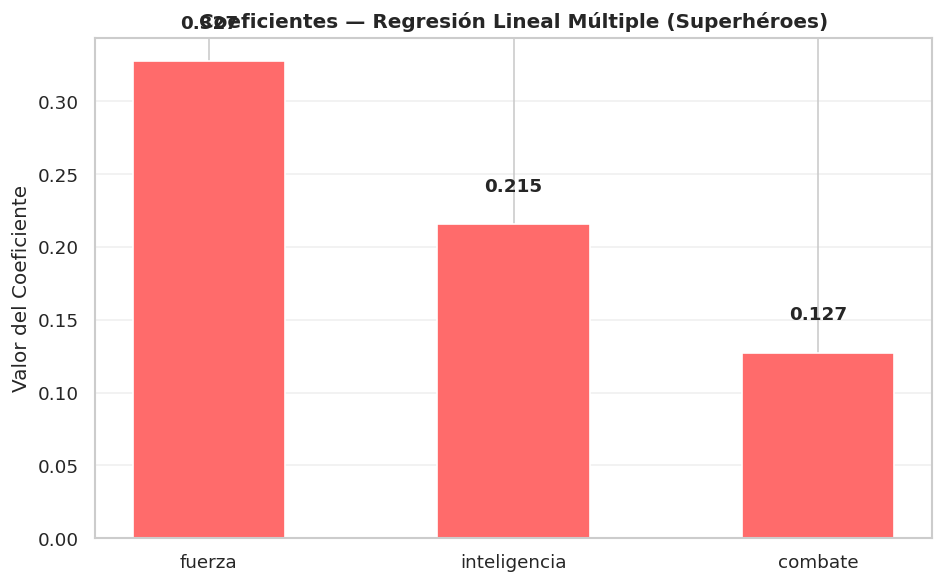

In [18]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    FEATURES,
    modelo_multi.coef_,
    color=colores,
    edgecolor='white',
    width=0.5
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title(
    'Coeficientes — Regresión Lineal Múltiple (Superhéroes)',
    fontsize=12,
    fontweight='bold'
)
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.02 if coef >= 0 else -0.04
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{coef:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../data/graficas/coeficientes_multi_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 18 — Métricas del modelo múltiple
Comparación del rendimiento del modelo múltiple. 📏

In [19]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 55)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (SUPERHÉROES)")
print("=" * 55)
print(f"  R²   (coef. determinación) : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático)   : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)       : {rmse_m:.4f}")
print(f"  MAE  (error absoluto)     : {mae_m:.4f}")
print("=" * 55)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (SUPERHÉROES)
  R²   (coef. determinación) : 0.3944  (39.44%)
  MSE  (error cuadrático)   : 33.5811
  RMSE (raíz del MSE)       : 5.7949
  MAE  (error absoluto)     : 4.6598


### Celda 19 — Resumen OLS múltiple
Análisis estadístico completo del modelo. 📚

In [20]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────

# Usar exactamente el mismo dataset limpio
X_ols_m = sm.add_constant(df_modelo_multi[FEATURES])
y_ols_m = df_modelo_multi['poder']

modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  poder   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     700.5
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:18:06   Log-Likelihood:                -11394.
No. Observations:                3535   AIC:                         2.280e+04
Df Residuals:                    3531   BIC:                         2.282e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.7398      1.144     20.761   

### Celda 20 — Cálculo de Multicolinealidad VIF
Detección de redundancia entre variables. ⚠️

In [21]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

X_vif = df_modelo_multi[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: (
        "✅ Sin multicolinealidad (VIF < 5)"
        if v < 5 else
        "⚠️ Moderada (5 ≤ VIF < 10)"
        if v < 10 else
        "❌ Severa (VIF ≥ 10)"
    )
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
    Variable    VIF            Criterio
      fuerza 15.788 ❌ Severa (VIF ≥ 10)
inteligencia 16.356 ❌ Severa (VIF ≥ 10)
     combate 28.606 ❌ Severa (VIF ≥ 10)


### Celda 21 — Diagnósticos visuales y tests estadísticos
Validación de supuestos del modelo múltiple. 🔍

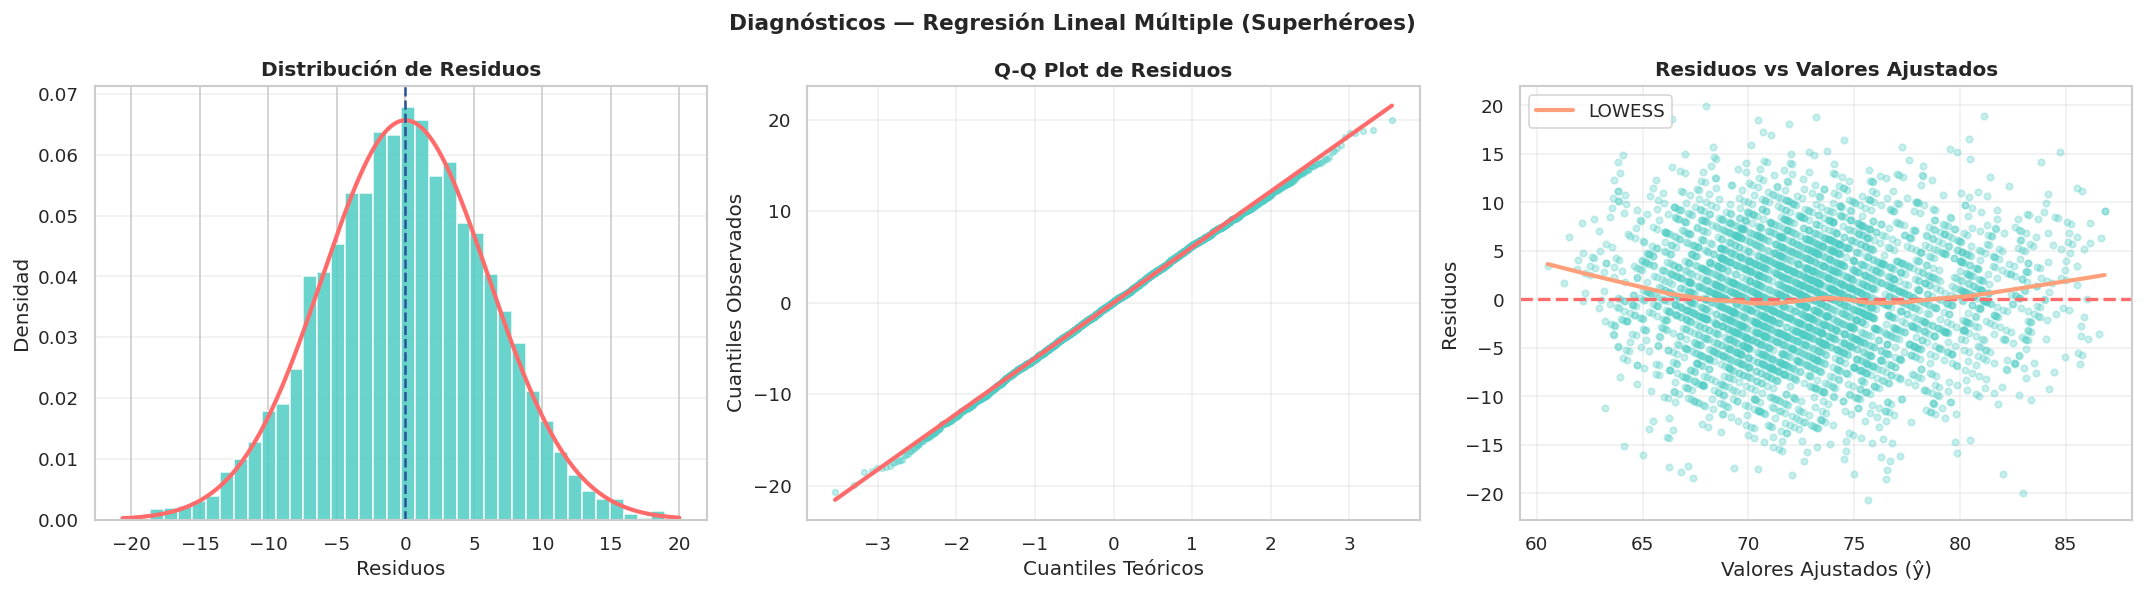


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.332492 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.000000 → ⚠️ Heterocedasticidad detectada


In [22]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────

residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Diagnósticos — Regresión Lineal Múltiple (Superhéroes)',
    fontsize=13,
    fontweight='bold'
)

# ── Histograma de residuos
axes[0].hist(
    residuos_m,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
    color='#ff6b6b',
    linewidth=2.5
)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(
    ajustados_m,
    residuos_m,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(
    lowess_m[:, 0],
    lowess_m[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='LOWESS'
)
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/diagnosticos_multi_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# ── Tests estadísticos
rng = np.random.default_rng(42)
muestra_m = (
    residuos_m if len(residuos_m) <= 5000
    else rng.choice(residuos_m, 5000, replace=False)
)

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    residuos_m,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(
    f"   p-value: {p_sw_m:.6f} → "
    f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}"
)

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(
    f"   p-value: {lm_p_m:.6f} → "
    f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}"
)

# 📌 Fase 6 - Diagnósticos Consolidados y Comparación de Modelos
Evaluación final para seleccionar el mejor modelo.

### Celda 22 — Tabla comparativa de métricas
Comparación de métricas entre modelos. ⚖️

In [23]:
# ── CELDA 22: Comparación final de modelos ───────────────────

comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': [
        'fuerza',
        'fuerza + inteligencia + combate'
    ],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    'BIC'      : [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("=" * 80)
print("          COMPARACIÓN FINAL DE MODELOS — SUPERHÉROES")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")

          COMPARACIÓN FINAL DE MODELOS — SUPERHÉROES
            Modelo                       Variables     R²  R² Aj.   RMSE    MAE      AIC      BIC
  Regresión Simple                          fuerza 0.1669  0.1555 6.7969 5.3912 23843.18 23855.52
Regresión Múltiple fuerza + inteligencia + combate 0.3944  0.3726 5.7949 4.6598 22795.03 22819.71

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


### Celda 23 — Gráfica de predicciones vs valores reales
Evaluación visual del desempeño de los modelos. 🎯

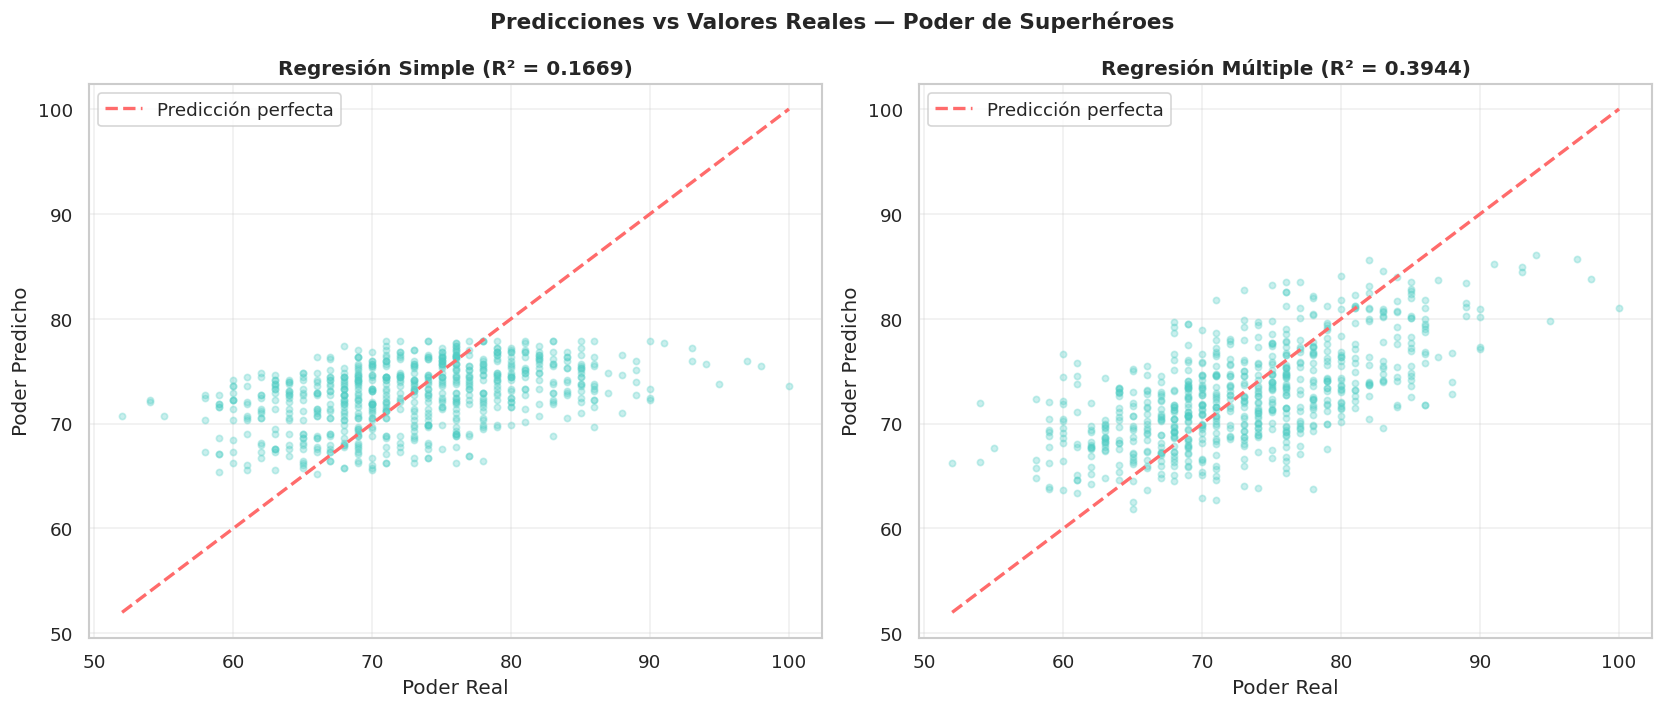

In [24]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Predicciones vs Valores Reales — Poder de Superhéroes',
    fontsize=13,
    fontweight='bold'
)

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    # Scatter
    ax.scatter(
        y_real,
        y_pred,
        alpha=0.30,
        s=14,
        color='#4ecdc4'
    )

    # Línea ideal y = x
    ax.plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    # R² del modelo
    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Poder Real')
    ax.set_ylabel('Poder Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/predicciones_vs_reales_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()